# RNN fading-memory experiment

In [1]:
from functools import partial

import torch

from rnn import (
    LearnableSequenceDataset,
    VanillaRNNRegressor,
    combine_sequence_regularizers,
    make_rnn_regressor,
    sequence_variance_floor,
    temporal_difference_floor,
)
from rnn_evaluation import (
    evaluate_fading_memory,
    evaluate_fading_memory_with_noise,
    predict_complete_sequences,
    print_fading_memory_summary,
    train_sequence_model,
)
from rnn_meta_learning import SequenceMetaLearner
from visualization import (
    plot_fading_memory,
    plot_generated_sequences,
    plot_sequence_meta_loss,
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Configuration

In [ ]:
# Generated sequences
SEED = 42
NUM_SEQUENCES = 24
SEQUENCE_LENGTH = 300
CONTEXT_LENGTH = 30

# RNN learner
HIDDEN_SIZE = 16
INNER_LR = 0.1
INNER_STEPS = 5
TRAIN_FRACTION = 0.75
WINDOWS_PER_SPLIT = 128

# Meta-optimization
META_STEPS = 3000
META_LR = 1e-2

# Collapse prevention
VARIANCE_FLOOR = 0.05
VARIANCE_WEIGHT = 0.2
DIFFERENCE_FLOOR = 0.01
DIFFERENCE_WEIGHT = 0.2

# Fading-memory audit
AUDIT_TRIALS = 100
PERTURBATIONS_PER_LAG = 10
LAG_NOISE_STD = 0.5
AUDIT_TRAIN_WINDOWS = 512
AUDIT_TEST_WINDOWS = 512

torch.manual_seed(SEED)

## Meta-training

In [3]:
generator = LearnableSequenceDataset(
    num_sequences=NUM_SEQUENCES,
    sequence_length=SEQUENCE_LENGTH,
)

rnn_factory = partial(make_rnn_regressor, hidden_size=HIDDEN_SIZE)

regularizer = combine_sequence_regularizers(
    partial(
        sequence_variance_floor,
        minimum=VARIANCE_FLOOR,
        weight=VARIANCE_WEIGHT,
    ),
    partial(
        temporal_difference_floor,
        minimum=DIFFERENCE_FLOOR,
        weight=DIFFERENCE_WEIGHT,
    ),
)

meta_learner = SequenceMetaLearner(
    generator=generator,
    learner_factory=rnn_factory,
    context_length=CONTEXT_LENGTH,
    regularization_fn=regularizer,
    meta_lr=META_LR,
    inner_lr=INNER_LR,
    inner_steps=INNER_STEPS,
    train_fraction=TRAIN_FRACTION,
    windows_per_split=WINDOWS_PER_SPLIT,
    first_order=False,
    seed=SEED,
)

/opt/homebrew/lib/python3.11/site-packages/torch/nn/modules/module.py:975: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:499.)
  param_grad = param.grad


step=0001 loss=1.00661 mse=0.24829
step=0050 loss=0.97027 mse=0.18049
step=0100 loss=1.00280 mse=0.26254
step=0150 loss=1.00559 mse=0.33027
step=0200 loss=1.08004 mse=0.25637
step=0250 loss=1.01538 mse=0.27385
step=0300 loss=1.00324 mse=0.25592
step=0350 loss=1.01721 mse=0.23884
step=0400 loss=1.03125 mse=0.32274
step=0450 loss=1.00664 mse=0.30661
step=0500 loss=1.00754 mse=0.27044
step=0550 loss=1.03161 mse=0.29213
step=0600 loss=1.11300 mse=0.29910
step=0650 loss=1.01450 mse=0.28556
step=0700 loss=1.05125 mse=0.27340
step=0750 loss=1.01244 mse=0.32137
step=0800 loss=1.00902 mse=0.27593
step=0850 loss=1.01990 mse=0.35755
step=0900 loss=1.03935 mse=0.32520
step=0950 loss=0.98344 mse=0.35021
step=1000 loss=1.00454 mse=0.45615
step=1050 loss=1.00551 mse=0.29666
step=1100 loss=0.95579 mse=0.33829
step=1150 loss=1.02113 mse=0.36846
step=1200 loss=0.83984 mse=0.29284
step=1250 loss=0.83904 mse=0.41789
step=1300 loss=0.76964 mse=0.40718
step=1350 loss=0.81104 mse=0.43375
step=1400 loss=0.611

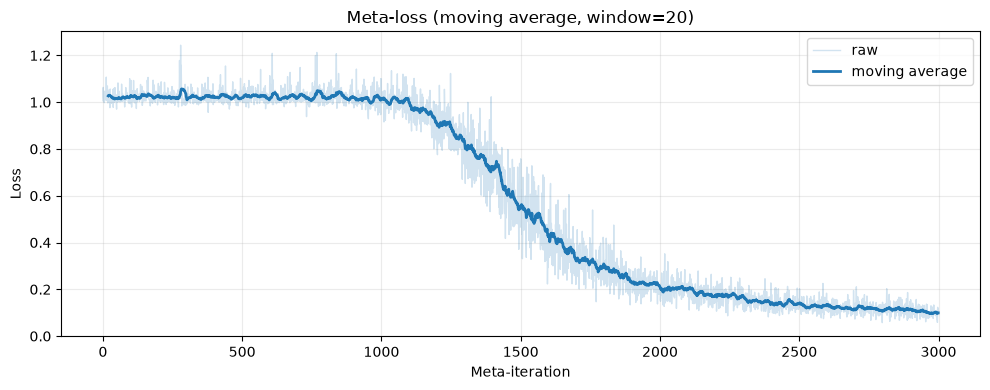

In [4]:
history = meta_learner.train(steps=META_STEPS, log_every=50)
sequences_frozen = meta_learner.frozen_sequences()

plot_sequence_meta_loss(history, smoothing_window=20);

## Predictions on held-out sequences

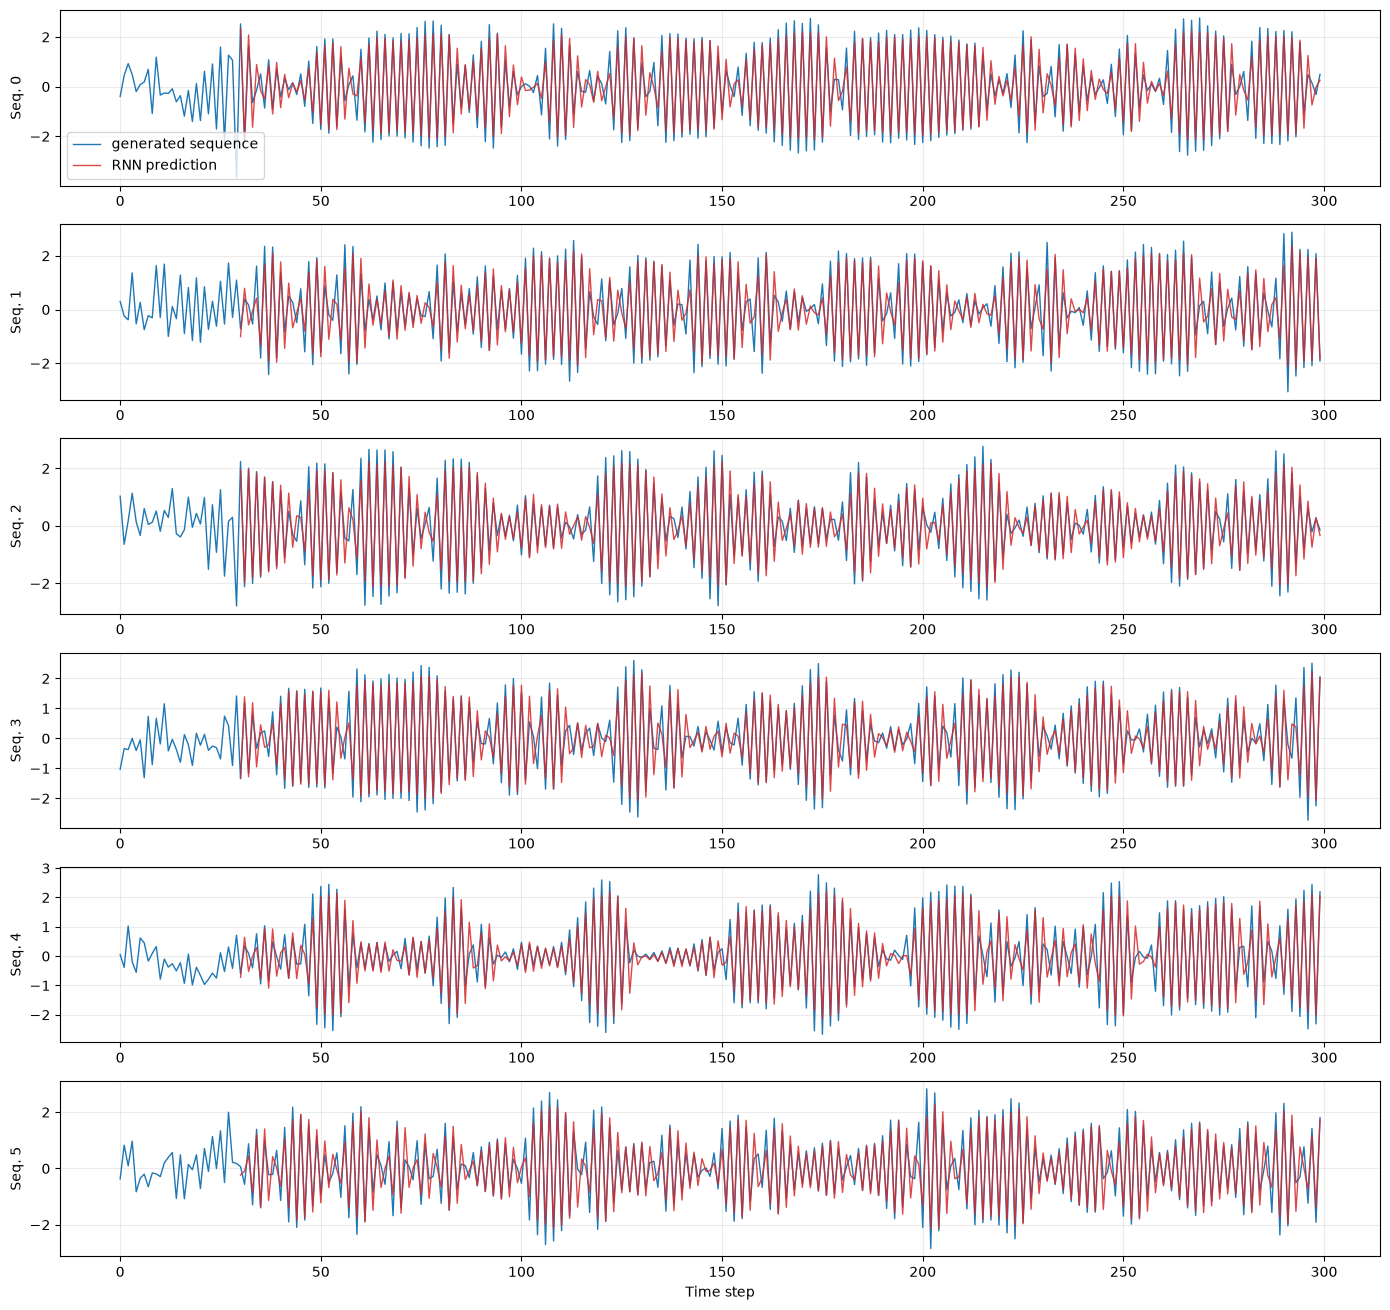

In [5]:
visualization_model, visualization_test_sequences = train_sequence_model(
    VanillaRNNRegressor,
    {"hidden_size": HIDDEN_SIZE},
    sequences_frozen,
    context_length=CONTEXT_LENGTH,
    train_fraction=TRAIN_FRACTION,
    training_steps=INNER_STEPS,
    learning_rate=INNER_LR,
    train_windows=AUDIT_TRAIN_WINDOWS,
    seed=5_000,
)
visualization_predictions = predict_complete_sequences(
    visualization_model,
    visualization_test_sequences,
    context_length=CONTEXT_LENGTH,
)
plot_generated_sequences(
    visualization_test_sequences,
    predictions=visualization_predictions,
    context_length=CONTEXT_LENGTH,
    count=6,
);

## Lag perturbation сheck

For every lag from 1 to 30, the corresponding value is replaced by the value at the same lag from another test context. Lag 1 is the most recent input and lag 30 is the oldest. A fading-memory pattern should produce larger prediction changes at recent lags and progressively smaller changes at older lags.

baseline MSE: 0.217451 +- 0.034809
most influential lags:
  lag   1: prediction shift 1.080530
  lag   2: prediction shift 0.376142
  lag   3: prediction shift 0.088777
  lag   4: prediction shift 0.028695
  lag   5: prediction shift 0.020476
  lag   6: prediction shift 0.012101
  lag   7: prediction shift 0.004877
  lag   8: prediction shift 0.002450
  lag   9: prediction shift 0.001477
  lag  10: prediction shift 0.000744


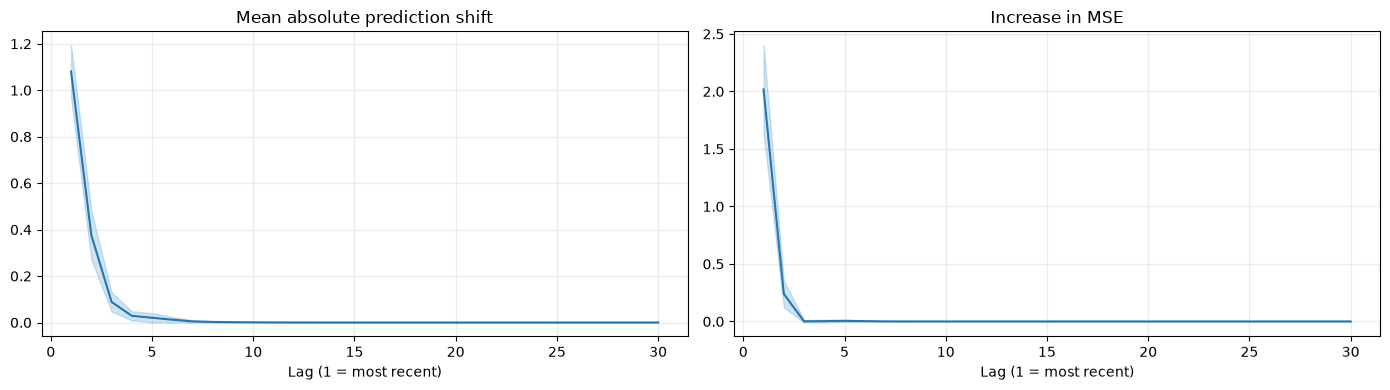

In [6]:
fading_summary = evaluate_fading_memory(
    VanillaRNNRegressor,
    {"hidden_size": HIDDEN_SIZE},
    sequences_frozen,
    context_length=CONTEXT_LENGTH,
    trials=AUDIT_TRIALS,
    perturbations_per_lag=PERTURBATIONS_PER_LAG,
    train_fraction=TRAIN_FRACTION,
    training_steps=INNER_STEPS,
    learning_rate=INNER_LR,
    train_windows=AUDIT_TRAIN_WINDOWS,
    test_windows=AUDIT_TEST_WINDOWS,
    seed=10_000,
)

print_fading_memory_summary(fading_summary)
plot_fading_memory(fading_summary);

## Lag noise check

This second check adds independent Gaussian noise to one selected lag instead of replacing it with a donor value. All other context elements remain unchanged.

baseline MSE: 0.227058 +- 0.035950
most influential lags:
  lag   1: prediction shift 0.355502
  lag   2: prediction shift 0.107306
  lag   3: prediction shift 0.023020
  lag   4: prediction shift 0.008040
  lag   5: prediction shift 0.005268
  lag   6: prediction shift 0.002931
  lag   7: prediction shift 0.001372
  lag   8: prediction shift 0.000616
  lag   9: prediction shift 0.000309
  lag  10: prediction shift 0.000170


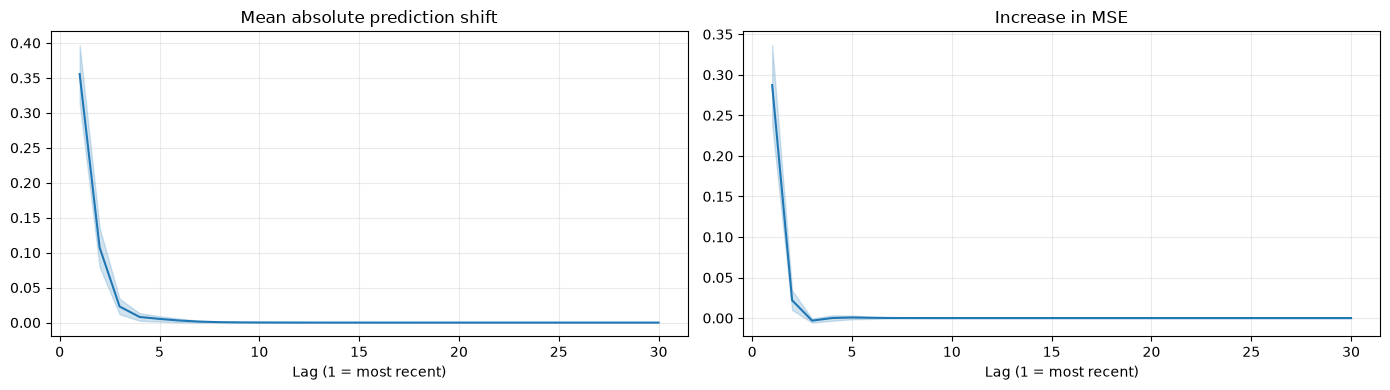

In [ ]:
noise_fading_summary = evaluate_fading_memory_with_noise(
    VanillaRNNRegressor,
    {"hidden_size": HIDDEN_SIZE},
    sequences_frozen,
    context_length=CONTEXT_LENGTH,
    noise_std=LAG_NOISE_STD,
    trials=AUDIT_TRIALS,
    perturbations_per_lag=PERTURBATIONS_PER_LAG,
    train_fraction=TRAIN_FRACTION,
    training_steps=INNER_STEPS,
    learning_rate=INNER_LR,
    train_windows=AUDIT_TRAIN_WINDOWS,
    test_windows=AUDIT_TEST_WINDOWS,
    seed=20_000,
)

print_fading_memory_summary(noise_fading_summary)
plot_fading_memory(noise_fading_summary);